# 11 Fast-Feature Transformer: MSE vs QLIKE

This notebook tests exactly the two fast-feature transformer variants that looked visually strongest in the earlier notebooks:

- `baseline_fast` from notebook 07,
- `regularized_small_fast_current` from notebook 08.

For each architecture, we train it twice:

- once with the original `MSE` loss on `log_fvol_5d`,
- once with `QLIKE`.

That gives a very direct answer to your question: **if we keep those two fast-feature models fixed, does switching the loss to QLIKE help?**

In [1]:
from pathlib import Path
import copy
import math
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

PROJECT_DIR = Path('/Users/chonggu/Documents/Mine/Erdos 2026 Spring final project')
DATA_DIR = PROJECT_DIR / 'data'
FIGURE_DIR = PROJECT_DIR / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DF_PATH = DATA_DIR / 'model_df_2016_2025.csv.gz'

try:
    mpl_dir = PROJECT_DIR / '.matplotlib'
    mpl_dir.mkdir(exist_ok=True)
except PermissionError:
    mpl_dir = Path('/tmp/erdos_vol_pred_runtime/.matplotlib')
    mpl_dir.mkdir(parents=True, exist_ok=True)

os.environ['MPLCONFIGDIR'] = str(mpl_dir)

assert MODEL_DF_PATH.exists(), f'Run 01_data_download_and_features.ipynb first: {MODEL_DF_PATH}'

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

DEVICE

device(type='mps')

## Fixed fast feature set

Both models here use the same `fast_current` feature set from the earlier tuning notebooks. The only differences are the architecture size and the loss.

In [2]:
model_df = pd.read_csv(MODEL_DF_PATH, parse_dates=['Date']).sort_values(['Ticker', 'Date']).reset_index(drop=True)

feature_list = [
    'abs_return', 'squared_return', 'high_low_log_range', 'log_volume',
    'realized_vol_5d', 'realized_vol_21d', 'realized_vol_63d',
    'hist_vol_5d', 'hist_vol_21d',
    'volume_zscore_21d', 'abs_return_mean_5d', 'parkinson_vol_5d',
    'mkt_SPY_proxy_return', 'mkt_SPY_proxy_hist_vol_5d',
    'mkt_QQQ_proxy_return', 'mkt_QQQ_proxy_hist_vol_21d',
    'mkt_IWM_proxy_return',
    'macro_^VIX_proxy_level_zscore_21d', 'macro_^TNX_proxy_return',
    'macro_HYG_proxy_return', 'macro_LQD_proxy_return',
    'volume_zscore_5d', 'return_mean_5d', 'realized_vol_10d', 'parkinson_vol_21d',
    'mkt_SPY_proxy_range', 'mkt_QQQ_proxy_range', 'mkt_IWM_proxy_range',
    'macro_^VIX_proxy_return', 'macro_^VIX_proxy_hist_vol_5d', 'macro_^VIX_proxy_range',
]

selected_tickers = ['AAPL', 'MSFT', 'NVDA', 'JPM', 'XOM']
target_columns = ['Date', 'Ticker', 'fvol_5d', 'log_fvol_5d']
train_end_year = 2023
validation_year = 2024
test_year = 2025

experiments = [
    {
        'experiment': 'baseline_fast_mse',
        'family': 'baseline_fast',
        'loss_name': 'mse',
        'lookback': 90,
        'd_model': 128,
        'dim_feedforward': 256,
        'dropout': 0.2,
        'learning_rate': 5e-4,
        'weight_decay': 5e-4,
    },
    {
        'experiment': 'baseline_fast_qlike',
        'family': 'baseline_fast',
        'loss_name': 'qlike',
        'lookback': 90,
        'd_model': 128,
        'dim_feedforward': 256,
        'dropout': 0.2,
        'learning_rate': 5e-4,
        'weight_decay': 5e-4,
    },
    {
        'experiment': 'regularized_small_fast_mse',
        'family': 'regularized_small_fast',
        'loss_name': 'mse',
        'lookback': 90,
        'd_model': 64,
        'dim_feedforward': 128,
        'dropout': 0.3,
        'learning_rate': 3e-4,
        'weight_decay': 1e-3,
    },
    {
        'experiment': 'regularized_small_fast_qlike',
        'family': 'regularized_small_fast',
        'loss_name': 'qlike',
        'lookback': 90,
        'd_model': 64,
        'dim_feedforward': 128,
        'dropout': 0.3,
        'learning_rate': 3e-4,
        'weight_decay': 1e-3,
    },
]

shared_train_cfg = {'nhead': 4, 'num_layers': 2, 'ticker_embedding_dim': 8, 'batch_size': 512, 'epochs': 30, 'patience': 6}

display(pd.DataFrame({'feature_count': [len(feature_list)]}))
pd.DataFrame(experiments)

,feature_count
0,31


,experiment,family,loss_name,lookback,d_model,dim_feedforward,dropout,learning_rate,weight_decay
0,baseline_fast_mse,baseline_fast,mse,90,128,256,0.2,0.0005,0.0005
1,baseline_fast_qlike,baseline_fast,qlike,90,128,256,0.2,0.0005,0.0005
2,regularized_small_fast_mse,regularized_small_fast,mse,90,64,128,0.3,0.0003,0.0010
3,regularized_small_fast_qlike,regularized_small_fast,qlike,90,64,128,0.3,0.0003,0.0010


## Shared data and model utilities

This section is deliberately standard: a single-window transformer, the same train / validation / test split, and the same evaluation metrics as before.

In [3]:
class RollingSequenceDataset(Dataset):
    def __init__(self, grouped_data, ticker_to_idx, lookback, allowed_years):
        self.grouped_data = grouped_data
        self.ticker_to_idx = ticker_to_idx
        self.lookback = lookback
        self.allowed_years = set(allowed_years)
        self.samples = []
        for ticker, panel in grouped_data.items():
            for end_idx in range(lookback - 1, len(panel['dates'])):
                if panel['dates'][end_idx].year in self.allowed_years:
                    self.samples.append((ticker, end_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        ticker, end_idx = self.samples[idx]
        panel = self.grouped_data[ticker]
        start_idx = end_idx - self.lookback + 1
        x = panel['features'][start_idx:end_idx + 1]
        return {
            'x': torch.tensor(x, dtype=torch.float32),
            'ticker_idx': torch.tensor(self.ticker_to_idx[ticker], dtype=torch.long),
            'y_log': torch.tensor(panel['target_log'][end_idx], dtype=torch.float32),
            'y_vol': torch.tensor(panel['target_vol'][end_idx], dtype=torch.float32),
            'date': panel['dates'][end_idx].strftime('%Y-%m-%d'),
            'ticker': ticker,
        }

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

class VolatilityTransformer(nn.Module):
    def __init__(self, input_dim, num_tickers, d_model, nhead, num_layers, dim_feedforward, dropout, ticker_embedding_dim, max_len):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.positional_encoding = PositionalEncoding(d_model=d_model, dropout=dropout, max_len=max_len)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.ticker_embedding = nn.Embedding(num_tickers, ticker_embedding_dim)
        self.head = nn.Sequential(
            nn.Linear(d_model + ticker_embedding_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x, ticker_idx):
        x = self.input_proj(x)
        x = self.positional_encoding(x)
        encoded = self.encoder(x)
        sequence_repr = encoded[:, -1, :]
        ticker_repr = self.ticker_embedding(ticker_idx)
        output = self.head(torch.cat([sequence_repr, ticker_repr], dim=1)).squeeze(-1)
        return output

def prepare_data(feature_list, lookback, batch_size):
    experiment_df = model_df[target_columns + feature_list].copy().sort_values(['Ticker', 'Date']).reset_index(drop=True)
    train_mask = experiment_df['Date'].dt.year <= train_end_year
    feature_mean = experiment_df.loc[train_mask, feature_list].mean()
    feature_std = experiment_df.loc[train_mask, feature_list].std().replace(0, 1).fillna(1)
    experiment_df[feature_list] = (experiment_df[feature_list] - feature_mean) / feature_std
    ticker_levels = sorted(experiment_df['Ticker'].unique())
    ticker_to_idx = {ticker: idx for idx, ticker in enumerate(ticker_levels)}
    grouped_panels = {}
    for ticker, group in experiment_df.groupby('Ticker', sort=True):
        group = group.sort_values('Date').reset_index(drop=True)
        grouped_panels[ticker] = {
            'dates': group['Date'].tolist(),
            'features': group[feature_list].to_numpy(dtype=np.float32),
            'target_log': group['log_fvol_5d'].to_numpy(dtype=np.float32),
            'target_vol': group['fvol_5d'].to_numpy(dtype=np.float32),
        }
    train_dataset = RollingSequenceDataset(grouped_panels, ticker_to_idx, lookback, allowed_years=range(2016, train_end_year + 1))
    val_dataset = RollingSequenceDataset(grouped_panels, ticker_to_idx, lookback, allowed_years=[validation_year])
    test_dataset = RollingSequenceDataset(grouped_panels, ticker_to_idx, lookback, allowed_years=[test_year])
    return {
        'ticker_levels': ticker_levels,
        'train_loader': DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0),
        'val_loader': DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0),
        'test_loader': DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0),
    }

def compute_loss(loss_name, pred_log, y_log, y_vol):
    if loss_name == 'mse':
        return torch.mean((pred_log - y_log) ** 2)
    if loss_name == 'qlike':
        pred_log_clipped = torch.clamp(pred_log, min=-6.0, max=6.0)
        pred_var = torch.exp(2.0 * pred_log_clipped)
        true_var = torch.clamp(y_vol ** 2, min=1e-8)
        return torch.mean(torch.log(pred_var) + true_var / pred_var)
    raise ValueError(f'Unknown loss: {loss_name}')

def run_epoch(model, dataloader, loss_name, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    total_items = 0
    for batch in dataloader:
        x = batch['x'].to(DEVICE)
        ticker_idx = batch['ticker_idx'].to(DEVICE)
        y_log = batch['y_log'].to(DEVICE)
        y_vol = batch['y_vol'].to(DEVICE)
        with torch.set_grad_enabled(is_train):
            pred = model(x, ticker_idx)
            loss = compute_loss(loss_name, pred, y_log, y_vol)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
        batch_size = x.size(0)
        total_loss += loss.item() * batch_size
        total_items += batch_size
    return total_loss / total_items

@torch.no_grad()
def predict_dataset(model, dataloader):
    model.eval()
    rows = []
    for batch in dataloader:
        x = batch['x'].to(DEVICE)
        ticker_idx = batch['ticker_idx'].to(DEVICE)
        pred_log = model(x, ticker_idx).detach().cpu().numpy()
        pred_vol = np.exp(np.clip(pred_log, -6.0, 6.0))
        y_vol = batch['y_vol'].detach().cpu().numpy()
        for date, ticker, actual, prediction in zip(batch['date'], batch['ticker'], y_vol, pred_vol):
            rows.append({'Date': pd.to_datetime(date), 'Ticker': ticker, 'fvol_5d': float(actual), 'prediction': float(prediction)})
    return pd.DataFrame(rows)

def evaluate(prediction_df):
    y_true = np.asarray(prediction_df['fvol_5d'], dtype=float)
    y_pred = np.clip(np.asarray(prediction_df['prediction'], dtype=float), 1e-8, None)
    errors = y_true - y_pred
    corr = np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan
    return {
        'rmse': float(np.sqrt(np.mean(errors ** 2))),
        'mae': float(np.mean(np.abs(errors))),
        'qlike': float(np.mean(np.log(y_pred ** 2) + (y_true ** 2) / (y_pred ** 2))),
        'corr': float(corr),
    }

def train_experiment(spec):
    data = prepare_data(feature_list, lookback=spec['lookback'], batch_size=shared_train_cfg['batch_size'])
    model = VolatilityTransformer(
        input_dim=len(feature_list),
        num_tickers=len(data['ticker_levels']),
        d_model=spec['d_model'],
        nhead=shared_train_cfg['nhead'],
        num_layers=shared_train_cfg['num_layers'],
        dim_feedforward=spec['dim_feedforward'],
        dropout=spec['dropout'],
        ticker_embedding_dim=shared_train_cfg['ticker_embedding_dim'],
        max_len=spec['lookback'],
    ).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=spec['learning_rate'], weight_decay=spec['weight_decay'])
    best_state = None
    best_val_loss = float('inf')
    best_epoch = None
    epochs_without_improvement = 0
    history_rows = []
    for epoch in range(1, shared_train_cfg['epochs'] + 1):
        train_loss = run_epoch(model, data['train_loader'], spec['loss_name'], optimizer=optimizer)
        val_loss = run_epoch(model, data['val_loader'], spec['loss_name'], optimizer=None)
        history_rows.append({'experiment': spec['experiment'], 'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss})
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        print(f"{spec['experiment']} | epoch {epoch}/{shared_train_cfg['epochs']} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")
        if epochs_without_improvement >= shared_train_cfg['patience']:
            print(f"{spec['experiment']} | early stopping at epoch {epoch}. Best epoch: {best_epoch}.")
            break
    model.load_state_dict(best_state)
    val_predictions = predict_dataset(model, data['val_loader'])
    test_predictions = predict_dataset(model, data['test_loader'])
    val_metrics = evaluate(val_predictions)
    test_metrics = evaluate(test_predictions)
    summary = {
        'experiment': spec['experiment'],
        'family': spec['family'],
        'loss_name': spec['loss_name'],
        'lookback': spec['lookback'],
        'd_model': spec['d_model'],
        'dropout': spec['dropout'],
        'learning_rate': spec['learning_rate'],
        'weight_decay': spec['weight_decay'],
        'best_epoch': best_epoch,
        'val_rmse': val_metrics['rmse'],
        'val_mae': val_metrics['mae'],
        'val_qlike': val_metrics['qlike'],
        'val_corr': val_metrics['corr'],
        'test_rmse': test_metrics['rmse'],
        'test_mae': test_metrics['mae'],
        'test_qlike': test_metrics['qlike'],
        'test_corr': test_metrics['corr'],
    }
    return summary, pd.DataFrame(history_rows), test_predictions


## Run the four experiments

The cleanest comparison is within each `family`: compare the `mse` and `qlike` rows side by side.

In [4]:
summaries = []
history_frames = []
test_prediction_map = {}

for spec in experiments:
    summary, history_df, test_predictions = train_experiment(spec)
    summaries.append(summary)
    history_frames.append(history_df)
    test_prediction_map[spec['experiment']] = test_predictions

summary_df = pd.DataFrame(summaries).sort_values(['family', 'loss_name']).reset_index(drop=True)
history_df = pd.concat(history_frames, ignore_index=True)
summary_df

baseline_fast_mse | epoch 1/30 | train_loss=0.287969 | val_loss=0.241150


baseline_fast_mse | epoch 2/30 | train_loss=0.229905 | val_loss=0.242519


baseline_fast_mse | epoch 3/30 | train_loss=0.217026 | val_loss=0.278383


baseline_fast_mse | epoch 4/30 | train_loss=0.207886 | val_loss=0.274000


baseline_fast_mse | epoch 5/30 | train_loss=0.199888 | val_loss=0.269092


...

regularized_small_fast_qlike | epoch 5/30 | train_loss=-1.781991 | val_loss=-1.759029


regularized_small_fast_qlike | epoch 6/30 | train_loss=-1.791909 | val_loss=-1.758280


regularized_small_fast_qlike | epoch 7/30 | train_loss=-1.797372 | val_loss=-1.761891


regularized_small_fast_qlike | epoch 8/30 | train_loss=-1.805601 | val_loss=-1.767464
regularized_small_fast_qlike | early stopping at epoch 8. Best epoch: 2.


,experiment,family,loss_name,lookback,d_model,dropout,learning_rate,weight_decay,best_epoch,val_rmse,val_mae,val_qlike,val_corr,test_rmse,test_mae,test_qlike,test_corr
0,baseline_fast_mse,baseline_fast,mse,90,128,0.2,0.0005,0.0005,1,0.141114,0.083209,-1.590929,0.456890,0.164249,0.099951,-1.341599,0.474459
1,baseline_fast_qlike,baseline_fast,qlike,90,128,0.2,0.0005,0.0005,10,0.141346,0.095390,-1.806468,0.482477,0.187003,0.126838,-1.288467,0.327249
2,regularized_small_fast_mse,regularized_small_fast,mse,90,64,0.3,0.0003,0.0010,10,0.142524,0.083077,-1.562211,0.455027,0.168980,0.098977,-1.221191,0.444069
3,regularized_small_fast_qlike,regularized_small_fast,qlike,90,64,0.3,0.0003,0.0010,2,0.145082,0.098794,-1.785285,0.442886,0.168472,0.113789,-1.516200,0.488452


In [5]:
comparison_df = summary_df[['family','loss_name','val_rmse','val_mae','val_qlike','val_corr','test_rmse','test_mae','test_qlike','test_corr']].copy()
comparison_df

,family,loss_name,val_rmse,val_mae,val_qlike,val_corr,test_rmse,test_mae,test_qlike,test_corr
0,baseline_fast,mse,0.141114,0.083209,-1.590929,0.456890,0.164249,0.099951,-1.341599,0.474459
1,baseline_fast,qlike,0.141346,0.095390,-1.806468,0.482477,0.187003,0.126838,-1.288467,0.327249
2,regularized_small_fast,mse,0.142524,0.083077,-1.562211,0.455027,0.168980,0.098977,-1.221191,0.444069
3,regularized_small_fast,qlike,0.145082,0.098794,-1.785285,0.442886,0.168472,0.113789,-1.516200,0.488452


## Five-stock comparison plot

This plot overlays the four experiments so you can directly see whether the QLIKE versions look better than the original MSE versions for these two fast-feature models.

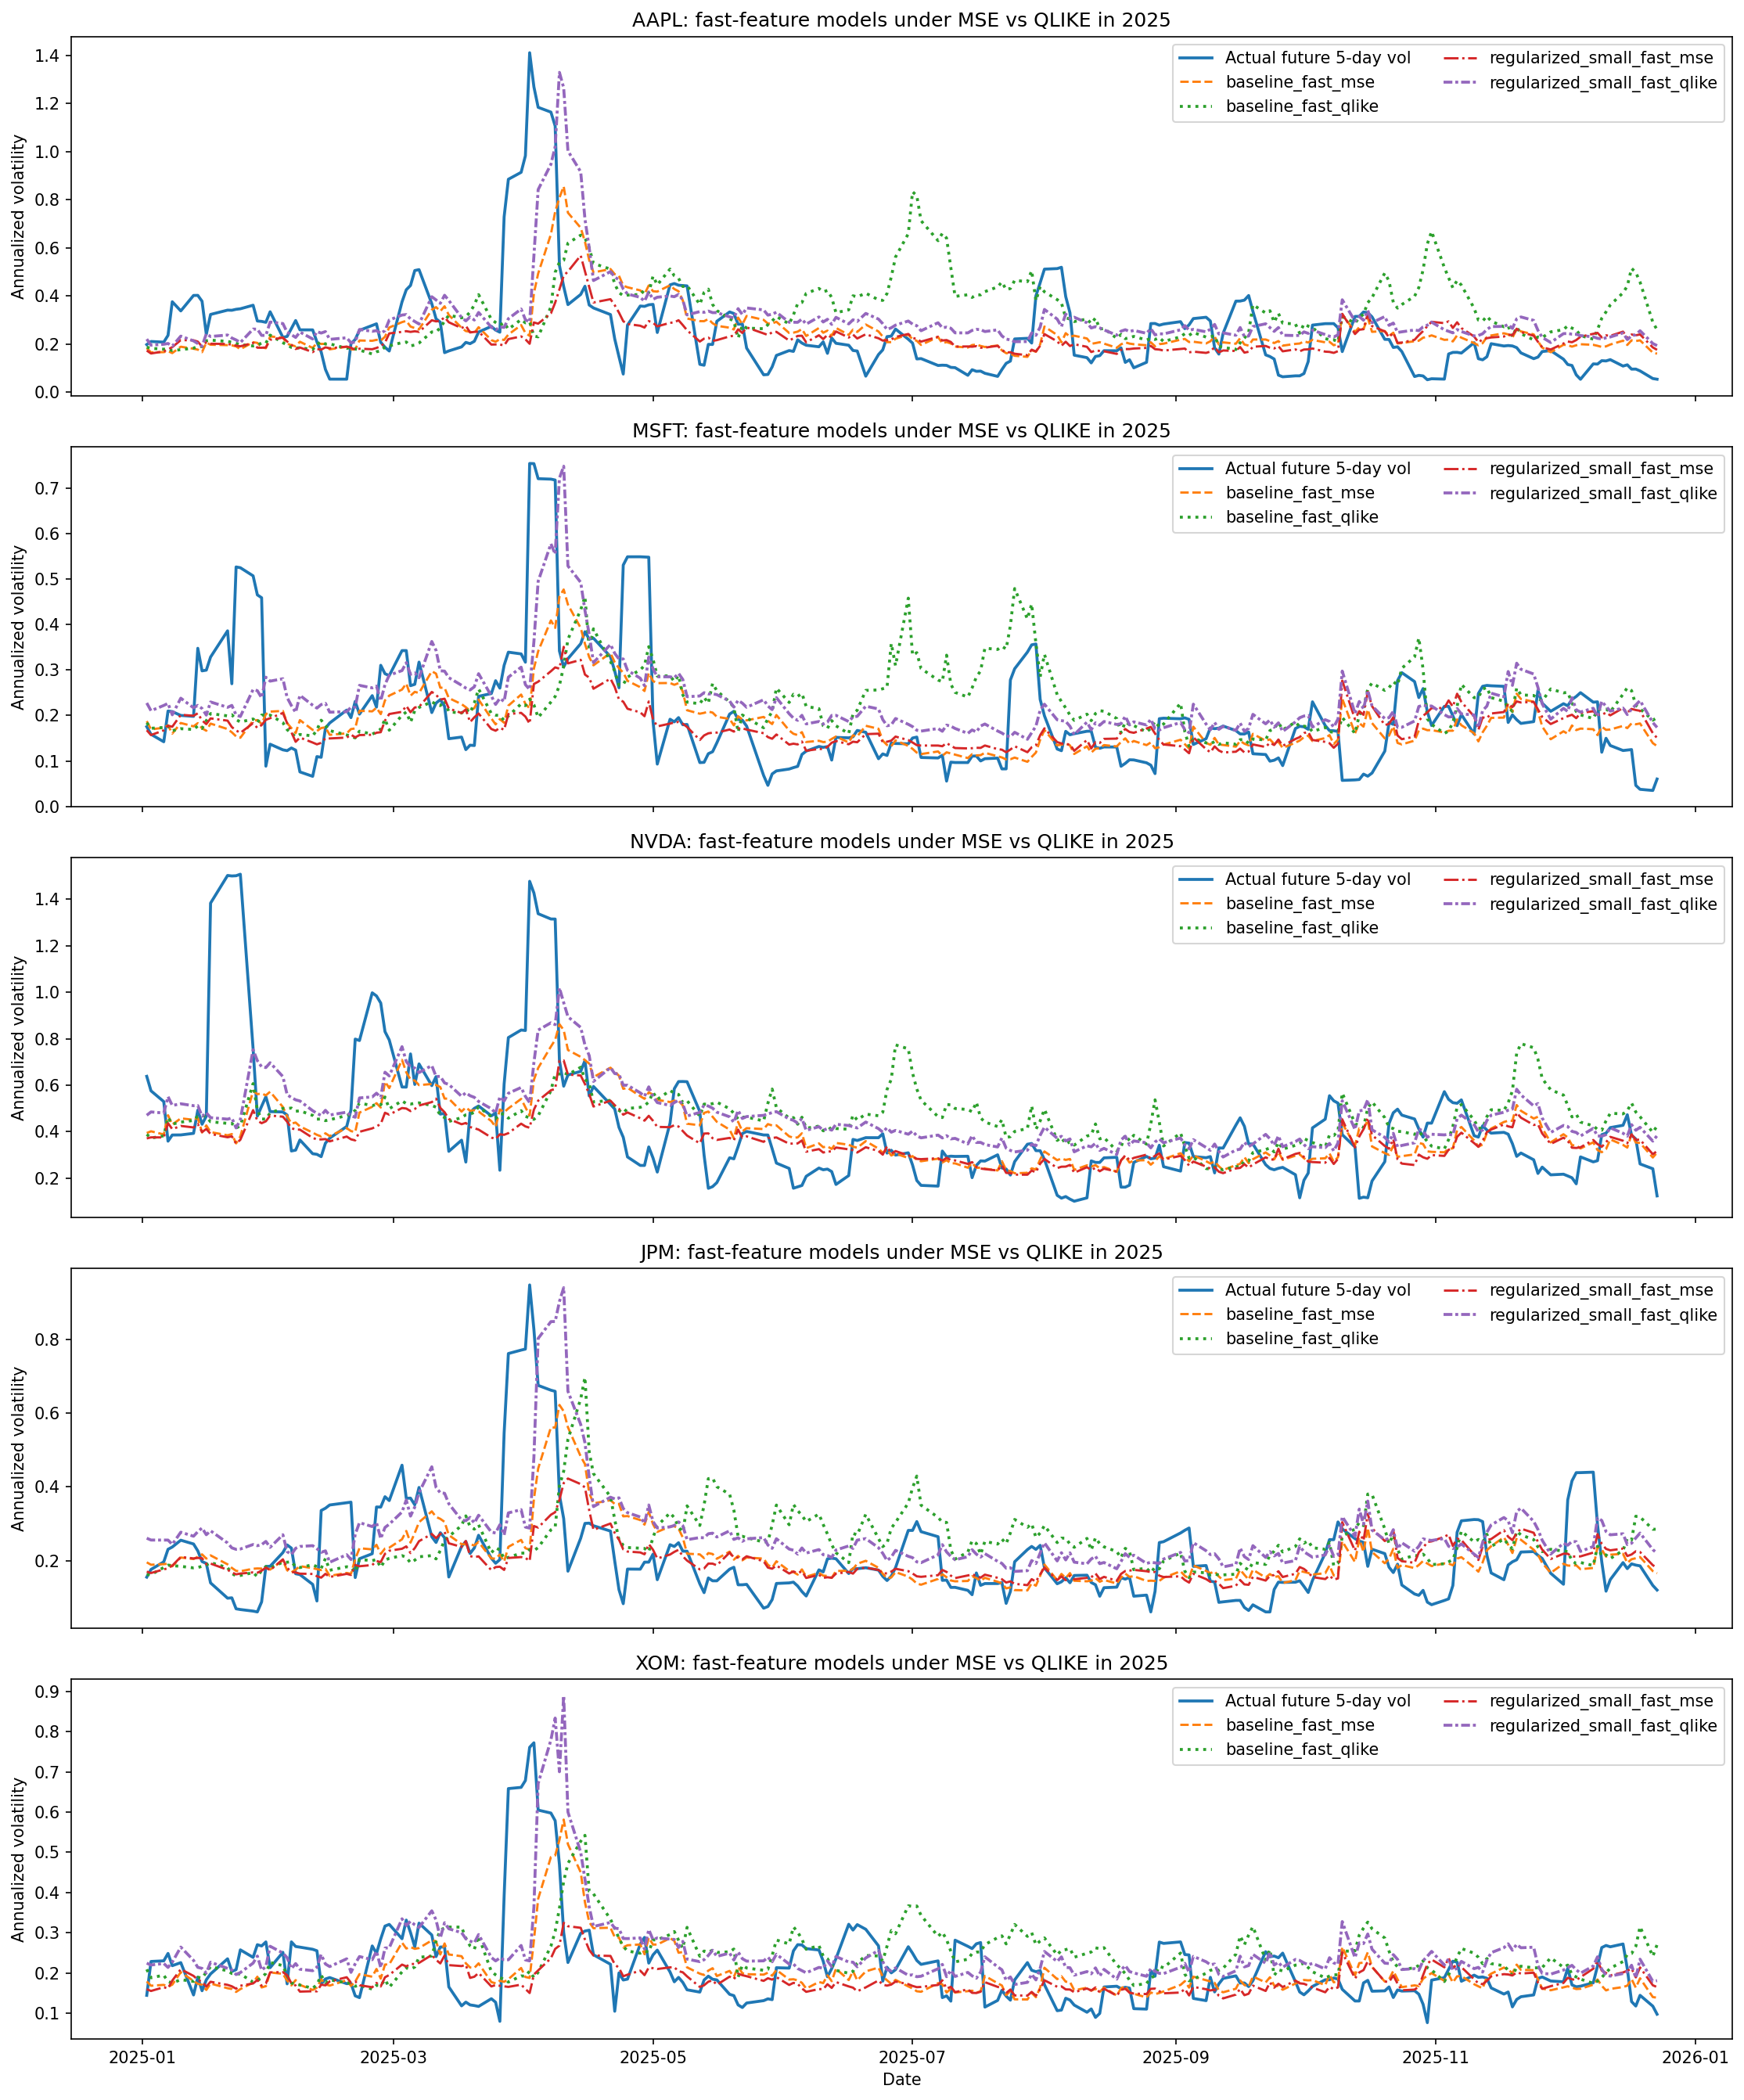

PosixPath('/Users/chonggu/Documents/Mine/Erdos 2026 Spring final project/figures/transformer_fast_feature_mse_vs_qlike_5stocks.png')

In [6]:
plot_order = ['baseline_fast_mse', 'baseline_fast_qlike', 'regularized_small_fast_mse', 'regularized_small_fast_qlike']
plot_df = test_prediction_map[plot_order[0]].rename(columns={'prediction': plot_order[0]})
for name in plot_order[1:]:
    plot_df = plot_df.merge(test_prediction_map[name][['Date', 'Ticker', 'prediction']].rename(columns={'prediction': name}), on=['Date','Ticker'], how='left')

fig, axes = plt.subplots(len(selected_tickers), 1, figsize=(15, 18), sharex=True)
styles = {
    'baseline_fast_mse': ('--', 1.4),
    'baseline_fast_qlike': (':', 1.8),
    'regularized_small_fast_mse': ('-.', 1.4),
    'regularized_small_fast_qlike': ((0, (3, 1, 1, 1)), 1.8),
}

for ax, ticker in zip(axes, selected_tickers):
    stock_plot_df = plot_df[plot_df['Ticker'] == ticker].sort_values('Date')
    ax.plot(stock_plot_df['Date'], stock_plot_df['fvol_5d'], label='Actual future 5-day vol', linewidth=1.8)
    for name in plot_order:
        linestyle, linewidth = styles[name]
        ax.plot(stock_plot_df['Date'], stock_plot_df[name], label=name, linestyle=linestyle, linewidth=linewidth)
    ax.set_title(f'{ticker}: fast-feature models under MSE vs QLIKE in 2025')
    ax.set_ylabel('Annualized volatility')
    ax.legend(loc='upper right', ncol=2)

axes[-1].set_xlabel('Date')
plt.tight_layout()

plot_path = FIGURE_DIR / 'transformer_fast_feature_mse_vs_qlike_5stocks.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(plot_path)))

plot_path

## How to interpret the result

Read the table within each model family:

- if the `qlike` row improves `test_qlike` and stays competitive on `RMSE / MAE`, then the loss switch is helping,
- if `qlike` also looks more responsive in the five-stock plot, that is extra evidence the change is worthwhile,
- if the MSE row still wins, then the earlier good-looking curve was probably coming more from the architecture / features than from the loss choice.